1440
2880


(-70.0, 70.0)

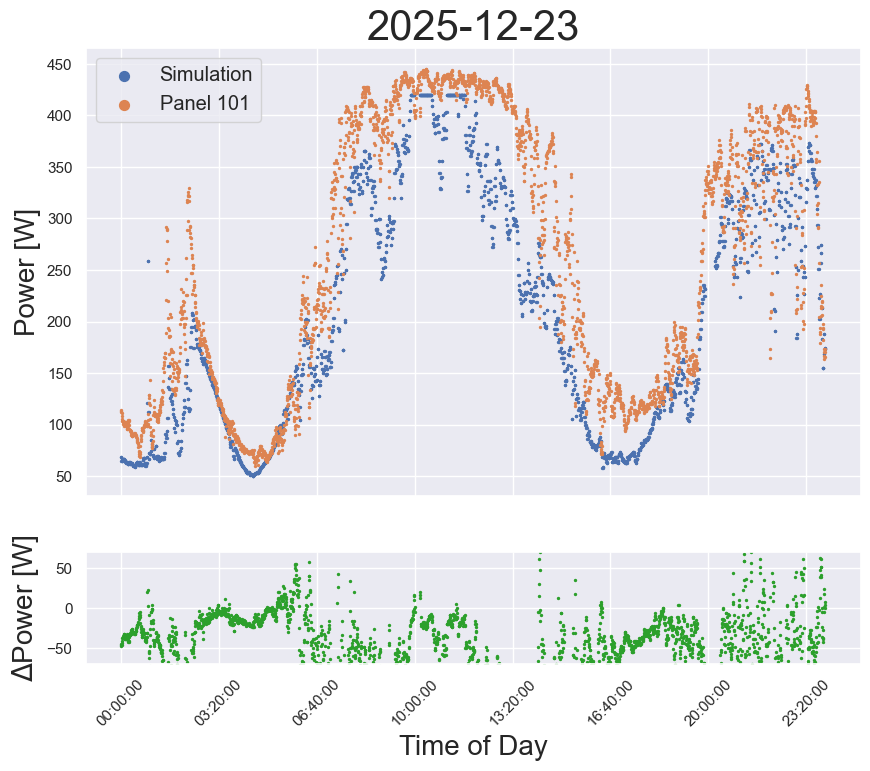

In [94]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np
import matplotlib.animation as animation
import matplotlib.gridspec as gridspec
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import os
import urllib.request
import random
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from numpy import trapezoid
from scipy.signal import argrelmin
import seaborn as sns
import math
from VerticalModelFunction import model as VerticalModel
import datetime
from SingleDayDataImporter import Import_NOAA_Data
from SingleDayDataImporter import Import_Panel_Data


# Global Variables
Area = 2.0 #m**2
baseurl = 'https://gml.noaa.gov/aftp/data/radiation/baseline/spo'
InputPath = '../../DataFolder'
OutputPath = 'PlotsFolder/'


year = 25
day = 357

def serial_date_to_string(year,srl_no):
    '''
    This function turns a day number and year to human readable date. Stole from stack overflow with minor modifactions
    '''
    # This will only work for years in this millenium!
    year_2 = year+2000
    # we need to use a 2 digit year
    new_date = datetime.datetime(year_2,1,1,0,0) + datetime.timedelta(srl_no - 1)
    return new_date.strftime("%Y-%m-%d")

direct_irradiance, diffuse_irradiance, upwelling_irradiance, NOAA_time, NOAA_zenith = Import_NOAA_Data(year,day)

voltage_101, voltage_103, current_101, current_103, power_101_og, power_103, time_101, time_103 = Import_Panel_Data(year,day)

zenith = np.nanmean(NOAA_zenith)
simulated_power_101 = VerticalModel(direct_irradiance, diffuse_irradiance, upwelling_irradiance,[0.24699832280882955,0.03850296370170911, 0.05890744297245301], 50, zenith, 110+180)
if len(power_101_og) <= 2880:
    difference = 2880 - len(power_101_og)
    power_101 = power_101_og
    for i in np.arange(0,difference,1):
        power_101 = np.append(power_101, np.nan)


print(len(simulated_power_101))
print(len(power_101))

# Gemini code for making a list of times: (Easaly verifiable!)
# ____________________________________________________________
# from datetime import datetime, timedelta
# Define parameters
start_time = datetime.datetime(2026, 1, 1, 0, 0)   
interval = datetime.timedelta(seconds=30)   
total_steps = 2880
# Generate list of string formatted times 
time_list = [(start_time + interval * i).strftime("%H:%M:%S") for i in range(total_steps)]
# ____________________________________________________________

# print(time_list)


# print(time_list)

sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize = (10,8), sharex = True)
ax[0].scatter(time_list, np.repeat(simulated_power_101,2), s = 2, label = 'Simulation')
ax[0].scatter(time_list, power_101, s = 2, label = 'Panel 101')

ax[1].set_xlabel('Time of Day', fontsize = 20)
ax[0].set_ylabel('Power [W]', fontsize = 20)


Date = serial_date_to_string(year, day)
ax[0].legend(markerscale = 5, fontsize = 'large')
ax[0].set_title(f'{Date}', fontsize = 30)
ax[1].scatter(time_list, np.repeat(simulated_power_101,2)-power_101, s = 2, label = 'Difference', color = 'tab:green')
ax[1].set_ylabel(r'$\Delta$Power [W]', fontsize = 20)
ax[1].set_xticks(np.linspace(0,2880,2880)[::400],labels =time_list[::400], rotation = 45)
ax[0].set_xticks(np.linspace(0,2880,2880)[::400],labels =time_list[::400], rotation = 45)
ax[1].set_ylim(-70,70)






